## Check reporter status for specific barcodes

In [59]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-02-04 18:07:25.821241


In [60]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [61]:
# plt.rcdefaults()

In [62]:
# plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['figure.figsize'] = (3,3)
# plt.rcParams["figure.dpi"] = 300

In [63]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [64]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

base_dir = BASE_DIR 

input_dir = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes"
input_file = input_dir / 'neurons-final-labels.h5ad' # using 1000 transcripts/cell filtering, final neuron_label

adata_480_path = base_dir / "data/h5ad/export_01/01b_filter/adata-480.h5ad"

print(input_file)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad


In [65]:
output_dir = os.path.join(base_dir, "figures_tables")

plot_out_dir = os.path.join(output_dir, "plots")
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

In [66]:
print(base_dir)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano


In [67]:
adata_480 = sc.read_h5ad(adata_480_path)

In [68]:
adata_480.shape

(72778, 480)

## Plotting functions

In [69]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

from scipy.stats import norm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

def plot_gaussian(adata_ref, 
                  genes = ["EGFP_Seq1", "dTomato_Seq2"],
                  gene_thresholds = (0.99, 0.99),
                  set_thresholds_on_dual_subsetted_data = False,
                  highlight_barcodes=None, 
                  highlight_color='orange',
                  highlight_size = 30,
                  save_path=None, 
                  return_reporter_classes=False,
                 show_histograms=False):
    
    # Work on copies to avoid unintended side effects
    adata_ref = adata_ref.copy()

    # Standardize gene names
    adata_ref.var_names = adata_ref.var_names.where(adata_ref.var_names != "tdTomato_Seq2", "dTomato_Seq2")
    
    # Ensure we are using raw counts for the math
    adata_ref.X = adata_ref.layers["counts"].copy()
    
    gauss_results = {}

    if set_thresholds_on_dual_subsetted_data: 
        # Raw counts for filtering
        egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
        td_raw_all   = to_dense(adata_ref[:, "dTomato_Seq2"].X)
        
        # Filter to include only cells with >1 raw count in both genes
        bg_filter_both_reporters = (egfp_raw_all > 1) & (td_raw_all > 1)

    for i, g in enumerate(genes):
        print(g)
        threshold_percentile = gene_thresholds[i]
        
        # 1. Get full expression vector for this gene
        x_raw_full = to_dense(adata_ref[:, g].X)
        x_log_full = np.log1p(x_raw_full)
        
        # 2. INDEPENDENT Background Filter
        # We only use cells with >1 count in THIS gene to model the noise
        specific_bg = x_raw_full > 1 

        # log distribution of cells that pass the gene specific background filter
        x_log_bg = x_log_full[specific_bg]
        
        # 3. Calculate Gaussian parameters from this gene's noise
        if set_thresholds_on_dual_subsetted_data:
            print('setting thresholds using cells with >1 count in both reporters')
            # log distribution of cells that pass the dual gene background filter
            x_log_bg_both_reporters = x_log_full[bg_filter_both_reporters]
            mu, sigma = np.mean(x_log_bg_both_reporters), np.std(x_log_bg_both_reporters)
        else:
            mu, sigma = np.mean(x_log_bg), np.std(x_log_bg)
        multiplier = norm.ppf(threshold_percentile)
        thr_log = mu + multiplier * sigma
        
        # 4. Apply threshold to ALL cells
        # Now a cell with 0 dTomato can still be EGFP_hi
        adata_ref.obs[f"{g}_hi"] = x_log_full > thr_log
        
        gauss_results[g] = {
            "full_log": x_log_full, 
            "thr_log": thr_log
        }
        print(f"{g}: {threshold_percentile} percentile threshold set at {thr_log:.3f} (Z={multiplier:.3f})")

        if show_histograms:
                    plt.figure(figsize=(4, 3))
                    # Plot the background distribution used for the model
                    plt.hist(x_log_bg, bins=100, color='gray', alpha=0.7)
                    # Add the threshold line
                    plt.axvline(thr_log, color='red', linestyle='--', label=f'Threshold: {thr_log:.2f}')
                    plt.title(f"Background Distribution: {g}")
                    plt.xlabel("log1p Expression")
                    plt.ylabel("Frequency")
                    plt.ylim(0,100)
                    plt.legend()
                    sns.despine()
                    plt.show() # This ensures the plot renders before the next loop iteration


    # Identify Dual-high (Logical AND of independent results)
    adata_ref.obs["EGFP_dTomato_dual_hi"] = (
        adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
    )

    # --- Highlight Logic ---
    is_highlight = adata_ref.obs_names.isin(highlight_barcodes) if highlight_barcodes is not None else np.zeros(adata_ref.n_obs, dtype=bool)
    
    # Define plotting groups
    dual_mask = adata_ref.obs["EGFP_dTomato_dual_hi"].values
    final_dual = dual_mask & ~is_highlight
    final_highlight = is_highlight
    
    # --- Plotting ---
    x_egfp = gauss_results["EGFP_Seq1"]["full_log"]
    x_td = gauss_results["dTomato_Seq2"]["full_log"]
    
    sns.set_theme(style="ticks")
    plt.figure(figsize=(3, 3), dpi=300)
    ax = plt.gca()

    # 1. All cells (Background)
    ax.scatter(x_egfp, x_td, s=2, color="lightgray", alpha=0.1, label="Background", rasterized=True)

    # 2. Dual Positive cells (Blue)
    if final_dual.any():
        ax.scatter(x_egfp[final_dual], x_td[final_dual], 
                   s=30, facecolors=(0.0, 0.47, 1.0, 0.4), edgecolors="blue", 
                   linewidths=0.8, label="Dual Positive")

    # 3. Highlighted cells (Orange/Custom) - Drawn last with high zorder
    if final_highlight.any():
        print(f"number of barcodes to highlight: {sum(final_highlight)}")
        ax.scatter(x_egfp[final_highlight], x_td[final_highlight], 
                   s=highlight_size, facecolors=highlight_color, 
                   alpha=1.0, label="Highlighted", zorder=10)

    # Threshold lines
    ax.axvline(gauss_results["EGFP_Seq1"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)
    ax.axhline(gauss_results["dTomato_Seq2"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)

    ax.set_xlabel("log1p EGFP_Seq1")
    ax.set_ylabel("log1p dTomato_Seq2")
    sns.despine()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    if return_reporter_classes:
        return adata_ref.obs[['sample_id', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']]

### Plot

In [70]:
highlight_barcodes_previously_missed=['acnndfag-1-0','bdfecjda-1-0','aceaecde-1-0']# previously not identified
highlight_barcodes_false_pos=['nefgajla-1-0'] # false positive

EGFP_Seq1
EGFP_Seq1: 0.9995 percentile threshold set at 3.425 (Z=3.291)
dTomato_Seq2
dTomato_Seq2: 0.999 percentile threshold set at 2.309 (Z=3.090)
number of barcodes to highlight: 3


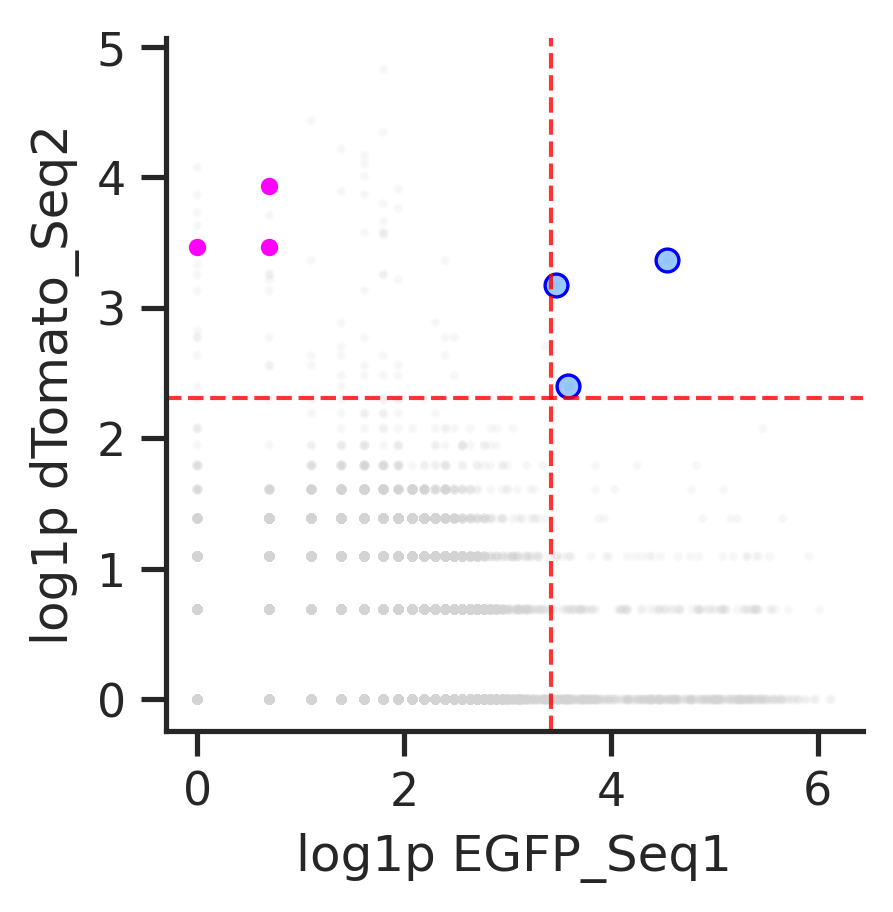

In [71]:
reporter_classes = plot_gaussian(adata_480, 
    genes = ["EGFP_Seq1", "dTomato_Seq2"],
    gene_thresholds = (0.9995, 0.999),
      highlight_barcodes = highlight_barcodes_previously_missed, 
              highlight_color = 'magenta', highlight_size=10,
    set_thresholds_on_dual_subsetted_data = False,
              return_reporter_classes=True
     )

EGFP_Seq1
EGFP_Seq1: 0.9995 percentile threshold set at 3.425 (Z=3.291)
dTomato_Seq2
dTomato_Seq2: 0.999 percentile threshold set at 2.309 (Z=3.090)
number of barcodes to highlight: 1


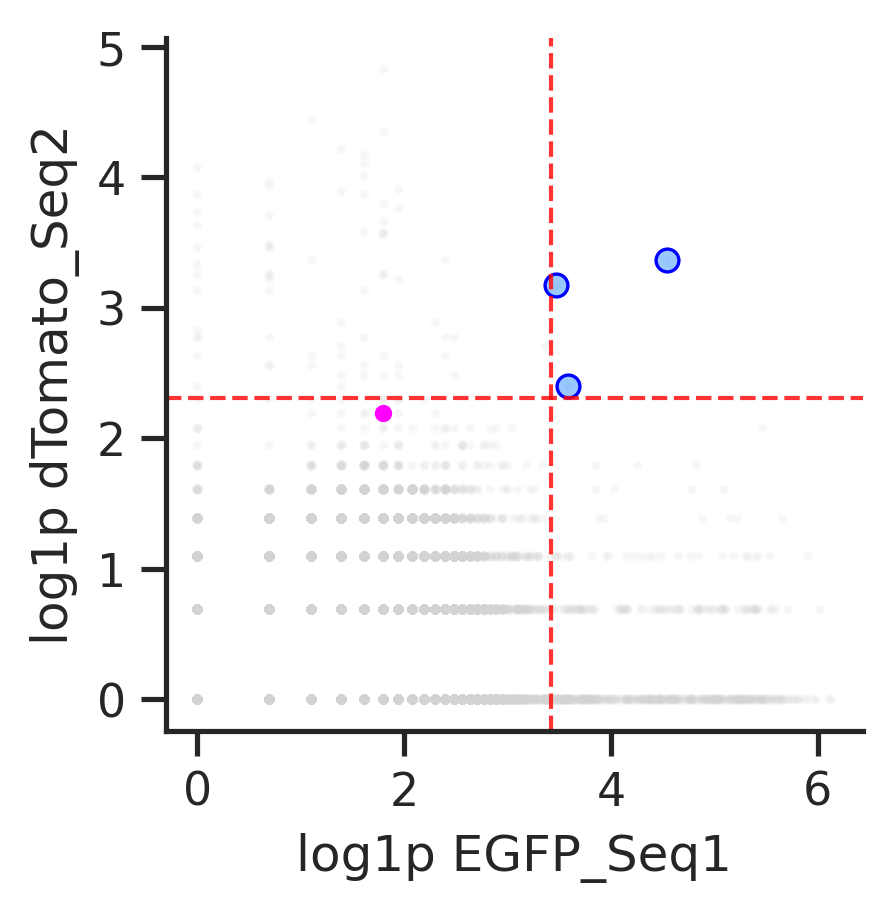

In [72]:
reporter_classes = plot_gaussian(adata_480, 
    genes = ["EGFP_Seq1", "dTomato_Seq2"],
    gene_thresholds = (0.9995, 0.999),
      highlight_barcodes = highlight_barcodes_false_pos, 
              highlight_color = 'magenta', highlight_size=10,
    set_thresholds_on_dual_subsetted_data = False,
              return_reporter_classes=True
     )